In [1]:
import pandas as pd
#pd.options.mode.chained_assignment = None
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

import yfinance as yf

In [79]:
df=pd.read_csv('data/Public_Restrooms_20260309.csv')
df['Changing Stations']=df['Changing Stations'].fillna('No')
df['Changing Stations']=[cs if cs in ['Yes', 'No'] else 'Partially' for cs in df['Changing Stations']]
df['Location Type']=[l if l in ['Park', 'Library'] else 'Other' for l in df['Location Type']]
df.head()

,Facility Name,Location Type,Operator,Status,Open,Hours of Operation,Accessibility,Restroom Type,Changing Stations,Additional Notes,Website,Latitude,Longitude,Location
0,Refinery Building,Park,Domino Park,Operational,Year Round,6am-11pm,NaN,NaN,No,NaN,NaN,40.714424,-73.967306,POINT (-73.967306 40.714424)
1,Maspeth Park,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",NaN,NaN,Yes,NaN,NaN,40.730900,-73.925400,POINT (-73.9254 40.7309)
2,"Fort Hamilton Library, BPL",Library,BPL,Operational,Year Round,Monday\t10 am - 6 pm\nTuesday\t1 pm - 8 pm\nWe...,Fully Accessible,Single-Stall All Gender Restroom(s),Yes,NaN,https://www.bklynlibrary.org/locations/fort-ha...,40.616381,-74.031371,POINT (-74.031371 40.616381)
3,Rienzi Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,No,NaN,NaN,40.887640,-73.858800,POINT (-73.8588 40.88764)
4,Lopez Playground,Park,NYC Parks,Operational,Year Round,"8am-4pm, Open later seasonally",Fully Accessible,Multi-Stall W/M Restrooms,No,NaN,NaN,40.611270,-74.085000,POINT (-74.085 40.61127)


In [80]:
df_grouped=df.groupby(['Open', 'Location Type', 'Changing Stations']).Open.count().reset_index(name='count')
df_grouped

,Open,Location Type,Changing Stations,count
0,Seasonal,Park,No,35
1,Seasonal,Park,Partially,24
2,Seasonal,Park,Yes,73
3,Year Round,Library,No,29
4,Year Round,Library,Partially,29
5,Year Round,Library,Yes,141
6,Year Round,Other,No,18
7,Year Round,Other,Partially,2
8,Year Round,Other,Yes,5
9,Year Round,Park,No,144


In [81]:
set1=df_grouped['Open'].unique().tolist()
set2=df_grouped['Location Type'].unique().tolist()
set3=df_grouped['Changing Stations'].unique().tolist()
set_dict={'Open':set1,
         'Location Type':set2,
         'Changing Stations': set3}
labels =set1+set2+set3
labels

['Seasonal',
 'Year Round',
 'Park',
 'Library',
 'Other',
 'No',
 'Partially',
 'Yes']

In [82]:
sets

['Open', 'Location Type', 'Changing Stations']

In [83]:
source=[]
target=[]
value=[]
sets=[k for k in set_dict]
for i, l in enumerate(sets):
    #stop before last set - no more connections from there
    if l!=sets[-1]:
        sources=df[l].unique()
        for s in sources:
            #source.append(labels.index(s))
            targets=df.loc[df[l]==s][sets[i+1]].unique().tolist()
            for t in targets:
                source.append(labels.index(s))
                target.append(labels.index(t))
                val=len(df.loc[(df[l]==s)&(df[sets[i+1]]==t)])
                value.append(val)

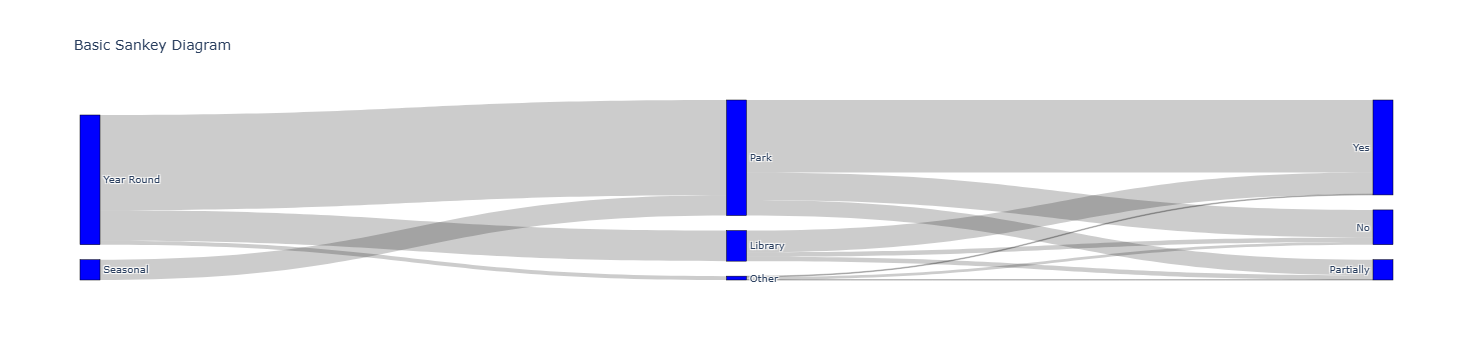

In [84]:
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = labels,
      color = "blue"
    ),
    link = dict(
      source = source, # indices correspond to labels, eg A1, A2, A1, B1, ...
      target = target,
      value = value
  ))])

fig.update_layout(title_text="Basic Sankey Diagram", font_size=10)
fig.show()